# DAY 1 — 초기 배터리 데이터와 수명 예측 설계

**박진원 · 울산 1반**

첫 100사이클에서 얻은 정보로 제공된 총수명 `cycle_life`를 예측하기 위한 분석입니다.
Batch 1·2·3의 분포, 열화 곡선, 초기 방전곡선 차이, 충전 조건과 변수의 관계를 확인합니다.
회귀와 분류 중에서는 **회귀**를 선택했습니다. 수명을 두 그룹으로만 나누기보다,
배터리 사이의 총사이클 수 차이를 연속적인 값으로 예측하려는 목적에 맞기 때문입니다.

- **분석 단위:** 배터리 셀 기록 한 개입니다. 사이클별 측정 행 수를 독립 배터리 수로 세지 않습니다.
  물리 셀 식별자는 미해독 상태이므로 서로 다른 기록의 물리적 중복이 없다고 확정하지는 않습니다.
- **입력 후보:** 100사이클 이내의 용량·온도·내부저항·충전 시간과 방전곡선 변화입니다.
- **예측할 값:** 원본의 제공 수명 라벨입니다. B1·B3는 80% 근처의 근사 종료 라벨이고,
  B2는 80% 임계값 교차를 관측한 라벨입니다. 이 차이를 유지하며 원본 값을 바꾸지 않습니다.
- **평가 설계:** B1 개발용 28개에서 교차검증과 모델 선택을 진행하고, 고정된 B1 holdout 8개와
  B2 39개에서 평가하도록 설계했습니다. B3 40개는 여기서 EDA에만 사용합니다.
  DAY2의 B3 추가 성능 평가는 선택 사항입니다.

이 노트북은 DAY1의 분석과 설계를 다룹니다. 모델 학습과 성능 결과는 DAY2 노트북에 정리되어 있습니다.
전체 배치를 비교하는 설명용 분석과 B1 개발용 데이터로 판단하는 모델 설계 근거를 구분했습니다.
holdout과 B2 분포를 EDA에서 확인했으므로, 이들을 전혀 관찰하지 않은 데이터라고 주장하지 않습니다.


## 1. 환경과 데이터 준비 상태

프로젝트 폴더 또는 `notebooks/`에서 실행할 수 있습니다. 원본 MAT 파일을 다시 읽는 대신,
준비 단계에서 만든 표와 사이클 10·100의 곡선을 사용합니다. 데이터 준비와 보완 분석이 완료된 상태에서
실행하며, 아래 코드는 데이터를 다운로드하거나 원본·정제·분할·모델 결과를 바꾸지 않습니다.


In [1]:
from pathlib import Path
import sys
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
ROOT = next((p for p in [cwd, *cwd.parents]
             if (p / 'src' / 'prepare_data.py').is_file()
             and (p / 'data' / 'processed').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('프로젝트 또는 notebooks 폴더에서 실행하세요.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
PROCESSED = ROOT / 'data' / 'processed'
BATCHES = {'Batch 1': 'batch1', 'Batch 2': 'batch2', 'Batch 3': 'batch3'}
COLORS = {'Batch 1': '#2878B5', 'Batch 2': '#D87526', 'Batch 3': '#369667'}
needed = [PROCESSED / f'{prefix}_{suffix}'
          for prefix in BATCHES.values()
          for suffix in ['cells.csv', 'summary.csv.gz', 'curves.npz']]
missing = [str(p.relative_to(ROOT)) for p in needed if not p.is_file()]
if missing:
    raise FileNotFoundError('데이터 준비가 필요합니다: ' + ', '.join(missing))
cohort_paths = [PROCESSED / 'cells_analysis.csv', ROOT / 'results' / 'cells_analysis.csv']
COHORT_PATH = next((p for p in cohort_paths if p.is_file()), None)
if COHORT_PATH is None:
    raise FileNotFoundError('데이터 품질 검토 결과 cells_analysis.csv가 필요합니다.')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11,
                     'axes.titlesize': 12, 'axes.labelsize': 11})
pd.set_option('display.max_columns', 25)
print('프로젝트:', ROOT)
print('Python:', sys.executable)
print('분석 대상 판정표:', COHORT_PATH.relative_to(ROOT))

SUPPLEMENT_PATH = ROOT / 'results' / 'day1_supplement.json'
if not SUPPLEMENT_PATH.is_file():
    raise FileNotFoundError('먼저 src/supplement_day1.py를 실행해 주세요.')
protected_paths = needed + [COHORT_PATH, ROOT/'results/degradation_slopes.csv',
                            ROOT/'results/split_assignment.csv']
input_hashes_before = {str(p.relative_to(ROOT)): hashlib.sha256(p.read_bytes()).hexdigest()
                       for p in protected_paths}


프로젝트: /Users/jinwon/workspace/데이터 분석 미니플젝
Python: /Users/jinwon/workspace/데이터 분석 미니플젝/.venv/bin/python
분석 대상 판정표: data/processed/cells_analysis.csv


In [2]:
raw_parts, summary_parts, curves = [], [], {}
for batch, prefix in BATCHES.items():
    part = pd.read_csv(PROCESSED / f'{prefix}_cells.csv',
                       dtype={'barcode': 'string', 'channel_id': 'string'})
    raw_parts.append(part)
    summary_parts.append(pd.read_csv(PROCESSED / f'{prefix}_summary.csv.gz'))
    with np.load(PROCESSED / f'{prefix}_curves.npz', allow_pickle=False) as archive:
        curves.update({name: archive[name].copy() for name in archive.files})
raw = pd.concat(raw_parts, ignore_index=True)
summary = pd.concat(summary_parts, ignore_index=True)
decisions = pd.read_csv(COHORT_PATH)
required = {'cell_id', 'analysis_eligible', 'exclusion_reason', 'cycle_life',
            'split_role', 'label_status'}
assert required.issubset(decisions.columns), f'판정표 필드 확인: {required - set(decisions.columns)}'
assert raw.cell_id.is_unique and decisions.cell_id.is_unique
assert set(raw.batch) == set(BATCHES), '세 배치의 준비 상태를 확인하세요.'
assert set(raw.cell_id) == set(decisions.cell_id), '원본과 판정표의 배터리 목록이 다릅니다.'
normalized = decisions.analysis_eligible.astype(str).str.lower().str.strip()
assert normalized.isin(['true', 'false', '1', '0']).all(), '분석 대상 판정값을 확인하세요.'
decisions['analysis_eligible'] = normalized.isin(['true', '1'])
# 원본 target은 덮어쓰지 않고, 별도의 분석용 target을 매핑한다.
cells = raw.merge(decisions[list(required)], on='cell_id', validate='one_to_one')
eligible = cells.loc[cells.analysis_eligible].copy()
assert eligible.cycle_life.notna().all() and (eligible.cycle_life > 0).all()
role_counts = eligible.split_role.value_counts()
assert role_counts.get('Batch1_CV_development', 0) == 28
assert role_counts.get('Batch1_holdout', 0) == 8
assert role_counts.get('Batch2_final_test', 0) == 39
assert eligible.loc[eligible.batch.eq('Batch 3'), 'split_role'].eq('Batch3_EDA_only').all()
print('기존 seed=42 분할 유지: Batch 1 개발 28 / holdout 8, Batch 2 평가 39')
display(cells[['batch', 'cell_id', 'policy', 'cycle_life_raw', 'cycle_life',
               'label_status', 'analysis_eligible', 'exclusion_reason']].head(8))
display(cells.groupby(['batch', 'split_role']).size().rename('battery_count').to_frame())


기존 seed=42 분할 유지: Batch 1 개발 28 / holdout 8, Batch 2 평가 39


,batch,cell_id,policy,cycle_life_raw,cycle_life,label_status,analysis_eligible,exclusion_reason
0,Batch 1,b1c0,3.6C(80%)-3.6C,1190.0,1190.0,unresolved_or_missing,False,원저자 B1 비완주 5개 또는 별도 후속기록 필요 5개; 확정 교차 또는 80% 근...
1,Batch 1,b1c1,3.6C(80%)-3.6C,1179.0,1179.0,unresolved_or_missing,False,원저자 B1 비완주 5개 또는 별도 후속기록 필요 5개; 확정 교차 또는 80% 근...
2,Batch 1,b1c2,3.6C(80%)-3.6C,1177.0,1177.0,unresolved_or_missing,False,원저자 B1 비완주 5개 또는 별도 후속기록 필요 5개; 확정 교차 또는 80% 근...
3,Batch 1,b1c3,4C(80%)-4C,1226.0,1226.0,unresolved_or_missing,False,원저자 B1 비완주 5개 또는 별도 후속기록 필요 5개; 확정 교차 또는 80% 근...
4,Batch 1,b1c4,4C(80%)-4C,1227.0,1227.0,unresolved_or_missing,False,원저자 B1 비완주 5개 또는 별도 후속기록 필요 5개; 확정 교차 또는 80% 근...
5,Batch 1,b1c5,4.4C(80%)-4.4C,1074.0,1074.0,provided_near80_endpoint_proxy,True,NaN
6,Batch 1,b1c6,4.8C(80%)-4.8C,636.0,636.0,provided_near80_endpoint_proxy,True,NaN
7,Batch 1,b1c7,4.8C(80%)-4.8C,870.0,870.0,provided_near80_endpoint_proxy,True,NaN


battery_count
batch   split_role                          
Batch 1 Batch1_CV_development             28
        Batch1_holdout                     8
        excluded                          10
Batch 2 Batch2_final_test                 39
        excluded                           8
Batch 3 Batch3_EDA_only                   40
        excluded                           6

## 2. 변수와 표의 단위

| 변수 | 뜻 | 분석에서의 역할 |
|---|---|---|
| `cell_id`, `barcode`, `batch` | 파일 내 ID, 물리 셀 식별자, 실험 배치 | 추적·분할에 사용하며 예측 입력에서는 제외합니다. |
| `cycle` | 충전·방전 반복 번호 | 예측 입력은 100사이클 이내로 제한합니다. |
| `QDischarge`, `QCharge` | 방전·충전 용량(Ah) | 초기 수준과 변화를 요약합니다. |
| `IR` | 내부저항 | 양수 측정값으로 초기 평균과 변화를 계산합니다. |
| `Tavg`, `Tmax`, `Tmin` | 사이클별 온도 요약 | 초기 온도 특성을 확인합니다. |
| `chargetime` | 충전 시간 | 초기 평균을 입력 후보로 사용합니다. |
| `Qdlin`, `Vdlin` | 전압 격자 위의 방전 용량과 전압 | 사이클 10·100의 곡선 차이를 계산합니다. |
| `cycle_life_raw`, `cycle_life` | 원본 및 분석용 제공 수명 라벨 | 값은 유지하고 품질 판정을 별도로 기록합니다. |
| `label_status` | 근사 종료·관측 교차·미해결 라벨 구분 | 라벨의 차이와 한계를 설명합니다. |

공칭 용량 1.1Ah의 80%는 **0.88Ah**입니다. 측정 오류나 관측 중단 여부를 함께 확인해야 하므로,
일시적으로 0.88Ah 아래로 내려갔다는 사실만으로 모든 기록의 수명을 확정하지는 않습니다.


In [3]:
inventory = raw.groupby('batch').agg(
    raw_cells=('cell_id', 'nunique'), cycle_rows=('n_summary', 'sum'),
    earliest_cycle=('first_cycle', 'min'), latest_cycle=('last_cycle', 'max'))
inventory['analysis_cells'] = eligible.groupby('batch').cell_id.nunique()
inventory['excluded_cells'] = inventory.raw_cells - inventory.analysis_cells.fillna(0)
display(inventory)
quality = summary.groupby('batch').agg(
    rows=('cell_id', 'size'), missing_qd=('QDischarge', lambda s: s.isna().sum()),
    zero_qd=('QDischarge', lambda s: (s == 0).sum()))
display(quality)
display(cells.loc[~cells.analysis_eligible,
                  ['batch', 'cell_id', 'cycle_life_raw', 'last_cycle', 'last_qd',
                   'first_below_80', 'exclusion_reason']])
display(cells.groupby(['batch', 'label_status', 'analysis_eligible']).size()
        .rename('cell_records').to_frame())
display(eligible.groupby('batch').agg(
    kept_cells=('cell_id', 'size'), min_final_qd=('last_qd', 'min'),
    max_final_qd=('last_qd', 'max')))
assert np.allclose(eligible.cycle_life, eligible.cycle_life_raw), '원본 라벨 변경 여부를 확인하세요.'


,raw_cells,cycle_rows,earliest_cycle,latest_cycle,analysis_cells,excluded_cells
batch,,,,,,
Batch 1,46,38811,1.0,1226.0,36,10
Batch 2,47,26904,1.0,1252.0,39,8
Batch 3,46,51007,1.0,2237.0,40,6


,rows,missing_qd,zero_qd
batch,,,
Batch 1,38811,0,46
Batch 2,26904,0,0
Batch 3,51007,0,0


,batch,cell_id,cycle_life_raw,last_cycle,last_qd,first_below_80,exclusion_reason
0,Batch 1,b1c0,1190.0,1189.0,1.026210,NaN,원저자 B1 비완주 5개 또는 별도 후속기록 필요 5개; 확정 교차 또는 80% 근...
1,Batch 1,b1c1,1179.0,1178.0,1.038225,NaN,원저자 B1 비완주 5개 또는 별도 후속기록 필요 5개; 확정 교차 또는 80% 근...
2,Batch 1,b1c2,1177.0,1176.0,1.043279,NaN,원저자 B1 비완주 5개 또는 별도 후속기록 필요 5개; 확정 교차 또는 80% 근...
3,Batch 1,b1c3,1226.0,1225.0,0.970921,NaN,원저자 B1 비완주 5개 또는 별도 후속기록 필요 5개; 확정 교차 또는 80% 근...
4,Batch 1,b1c4,1227.0,1226.0,1.021960,NaN,원저자 B1 비완주 5개 또는 별도 후속기록 필요 5개; 확정 교차 또는 80% 근...
8,Batch 1,b1c8,879.0,878.0,0.969025,NaN,원저자 B1 비완주 5개 또는 별도 후속기록 필요 5개; 확정 교차 또는 80% 근...
10,Batch 1,b1c10,906.0,905.0,0.961019,NaN,원저자 B1 비완주 5개 또는 별도 후속기록 필요 5개; 확정 교차 또는 80% 근...
12,Batch 1,b1c12,902.0,901.0,0.913119,NaN,원저자 B1 비완주 5개 또는 별도 후속기록 필요 5개; 확정 교차 또는 80% 근...
13,Batch 1,b1c13,897.0,896.0,0.923136,NaN,원저자 B1 비완주 5개 또는 별도 후속기록 필요 5개; 확정 교차 또는 80% 근...
22,Batch 1,b1c22,891.0,890.0,0.963279,NaN,원저자 B1 비완주 5개 또는 별도 후속기록 필요 5개; 확정 교차 또는 80% 근...


cell_records
batch   label_status                   analysis_eligible              
Batch 1 provided_near80_endpoint_proxy True                         36
        unresolved_or_missing          False                        10
Batch 2 observed_80pct_crossing        True                         39
        unresolved_or_missing          False                         8
Batch 3 provided_near80_endpoint_proxy True                         40
        unresolved_or_missing          False                         6

,kept_cells,min_final_qd,max_final_qd
batch,,,
Batch 1,36,0.880057,0.883363
Batch 2,39,0.825036,0.829404
Batch 3,40,0.880005,0.881670


**제외 근거와 라벨의 차이**

관측 중단, 라벨 부재와 원저자의 제외 근거를 사용했으며, 모델 점수를 보고 제외 대상을 고르지 않았습니다.
`capacity_plausible`의 0.2~1.5Ah는 탐색용 측정 점검 범위입니다. 이 범위가 새로운 물리 법칙이나 EOL 기준은 아닙니다.

- **B1:** 원본 46개의 라벨은 모두 `n_summary + 1`이며 엄격한 0.88Ah 교차가 관측되지 않았습니다.
  원저자 자료의 비완주 5개와 다른 날짜의 후속 기록 연결이 필요한 5개를 제외했습니다.
  남은 36개의 종료 용량은 약 0.88006~0.88336Ah입니다. 제공된 근사 종료 라벨을 그대로 유지했습니다.
- **B2:** 원본 47개 중 수명 라벨이 없는 8개를 제외했습니다. 남은 39개는 제공 수명과 최초 QD<0.88Ah 사이클이 일치했습니다.
- **B3:** 원본 46개 중 원저자 제외 목록의 6개(`b3c37/2/23/32/42/43`)를 분리했습니다.
  남은 40개는 모두 `n_summary + 1` 형태의 근사 종료 라벨입니다. 종료 용량은 약 0.880005~0.881670Ah입니다.

원본 **139개 중 115개(36/39/40)**를 분석했습니다. 원본 사이클 행 **116,722개**를 독립 배터리 수로 세지 않습니다.
0.885Ah는 종료 상태 점검값이며, EOL 기준을 바꾼 값은 아닙니다. B1·B3의 라벨을 B2와 동일하게 관측된 정답이라고
묶어서 설명하면 부정확합니다. 라벨 차이와 제외에 따른 분포 변화도 배치 간 평가의 한계에 포함합니다.

이번 B2 파일의 날짜는 `2018-02-20`이고, 원저자의 논문용 B2 로더는 `2017-06-30`을 사용합니다.
다른 파일에 적용된 셀 번호 보정이나 기록 연결을 그대로 복사하지 않았습니다.
논문의 MAPE 9.1%는 과제의 참고값이며, 이번 분석을 동일 조건의 재현이라고 표현하지 않습니다.


In [4]:
# batch_date는 기록된 값과 파일명 모두 확인한다.
metadata_rows = []
for batch, prefix in BATCHES.items():
    path = PROCESSED / f'{prefix}_metadata.json'
    if path.exists():
        meta = json.loads(path.read_text())
        metadata_rows.append({k: meta.get(k) for k in ['batch', 'file', 'batch_date', 'n_cells']})
display(pd.DataFrame(metadata_rows))
ids = cells[['batch', 'cell_id', 'barcode']].copy()
ids['barcode'] = ids.barcode.fillna('').astype(str).str.strip()
known_ids = ids.loc[ids.barcode.ne('')]
repeated = known_ids.groupby('barcode').batch.nunique()
cross_batch_barcodes = repeated[repeated > 1].index
display(known_ids.loc[known_ids.barcode.isin(cross_batch_barcodes)])
print('배치 간 겹치는 비어 있지 않은 barcode 수:', len(cross_batch_barcodes))
print('barcode 누락 수:', ids.barcode.eq('').sum(), '— 누락이면 중복이 없다고 확정할 수 없습니다.')


,batch,file,batch_date,n_cells
0,Batch 1,2017-05-12_batchdata_updated_struct_errorcorre...,2017-05-12,46
1,Batch 2,2018-02-20_batchdata_updated_struct_errorcorre...,2018-02-20,47
2,Batch 3,2018-04-12_batchdata_updated_struct_errorcorre...,2018-04-12,46


,batch,cell_id,barcode


배치 간 겹치는 비어 있지 않은 barcode 수: 0
barcode 누락 수: 139 — 누락이면 중복이 없다고 확정할 수 없습니다.


## 3. 수명 분포와 장·단수명 비율

원본의 제공 라벨과 분석 대상의 분포를 구분했습니다. 히스토그램은 과제에서 제시한 **150~2,300사이클** 범위를 사용합니다.
단수명 `<500`, 장수명 `>1,000`은 EDA용 구간이며 회귀 타깃을 이진화하는 기준이 아닙니다.
비율의 분모는 각 배치의 분석 대상 셀 수입니다.


,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
Batch 1,36.0,788.4,148.7,534.0,681.0,772.5,871.5,1074.0
Batch 2,39.0,565.7,222.2,392.0,439.5,472.0,508.5,1186.0
Batch 3,40.0,1032.0,308.6,541.0,827.2,964.5,1122.8,1935.0


life_group,Short: <500,Middle: 500–1000,Long: >1000
batch,,,
Batch 1,0,31,5
Batch 2,28,8,3
Batch 3,0,21,19


life_group,Short: <500 (%),Middle: 500–1000 (%),Long: >1000 (%)
batch,,,
Batch 1,0.0,86.1,13.9
Batch 2,71.8,20.5,7.7
Batch 3,0.0,52.5,47.5


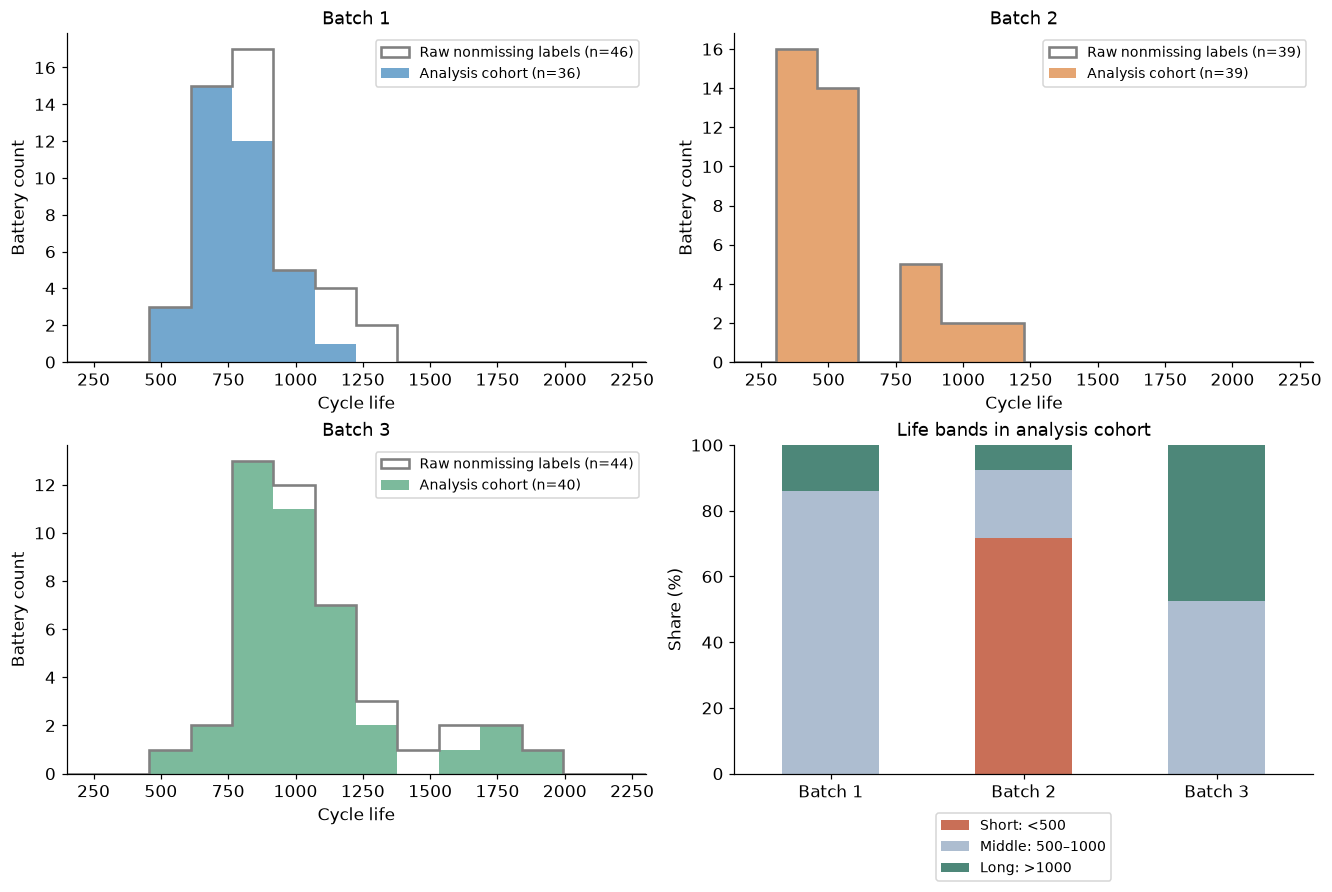

In [5]:
display(eligible.groupby('batch').cycle_life.describe().round(1))
life_bands = eligible[['batch', 'cell_id', 'cycle_life']].copy()
life_bands['life_group'] = np.select(
    [life_bands.cycle_life < 500, life_bands.cycle_life > 1000],
    ['Short: <500', 'Long: >1000'], default='Middle: 500–1000')
counts = pd.crosstab(life_bands.batch, life_bands.life_group).reindex(
    index=list(BATCHES),
    columns=['Short: <500', 'Middle: 500–1000', 'Long: >1000'], fill_value=0)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100
display(counts)
display(percentages.round(1).add_suffix(' (%)'))

bins = np.linspace(150, 2300, 15)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout='constrained')
for ax, batch in zip(axes.flat, BATCHES):
    raw_life = raw.loc[raw.batch.eq(batch), 'cycle_life_raw'].dropna()
    kept_life = eligible.loc[eligible.batch.eq(batch), 'cycle_life']
    ax.hist(raw_life, bins=bins, histtype='step', color='grey', linewidth=1.7,
            label=f'Raw nonmissing labels (n={len(raw_life)})')
    ax.hist(kept_life, bins=bins, alpha=.65, color=COLORS[batch],
            label=f'Analysis cohort (n={len(kept_life)})')
    ax.set(title=batch, xlabel='Cycle life', ylabel='Battery count', xlim=(150, 2300))
    ax.legend(fontsize=9)
percentages.plot.bar(stacked=True, ax=axes[1, 1],
                     color=['#C96F57', '#ADBDD0', '#4D8779'])
axes[1, 1].set(title='Life bands in analysis cohort', xlabel='', ylabel='Share (%)', ylim=(0, 100))
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].legend(fontsize=9, loc='upper center', bbox_to_anchor=(.5, -.1), ncol=1)
plt.show()


In [6]:
iqr_rows = []
for batch, group in eligible.groupby('batch'):
    q1, q3 = group.cycle_life.quantile([.25, .75])
    lower, upper = q1 - 1.5*(q3-q1), q3 + 1.5*(q3-q1)
    iqr_rows.append({'batch': batch, 'lower_fence': lower, 'upper_fence': upper,
                     'lower_outlier_ids': group.loc[group.cycle_life.lt(lower), 'cell_id'].tolist(),
                     'upper_outlier_ids': group.loc[group.cycle_life.gt(upper), 'cell_id'].tolist()})
display(pd.DataFrame(iqr_rows))
display(eligible.nsmallest(3, 'cycle_life')[['batch', 'cell_id', 'cycle_life', 'policy']])
b2 = eligible.loc[eligible.batch.eq('Batch 2')].copy()
b2['newstructure_label'] = b2.policy.str.contains('newstructure', case=False, na=False)
display(b2.groupby('newstructure_label').cycle_life.agg(['size', 'median', 'min', 'max']))


,batch,lower_fence,upper_fence,lower_outlier_ids,upper_outlier_ids
0,Batch 1,395.25,1157.25,[],[]
1,Batch 2,336.00,612.00,[],"[b2c7, b2c8, b2c9, b2c32, b2c33, b2c34, b2c43,..."
2,Batch 3,384.00,1566.00,[],"[b3c7, b3c16, b3c38, b3c45]"


,batch,cell_id,cycle_life,policy
65,Batch 2,b2c19,392.0,6C(60%)-3C
52,Batch 2,b2c6,393.0,3.6C(9%)-5C
61,Batch 2,b2c15,396.0,3.6C(9%)-5C


,size,median,min,max
newstructure_label,,,,
False,30,451.0,392.0,514.0
True,9,904.0,777.0,1186.0


B1·B2·B3의 장수명 비율은 각각 13.9%, 7.7%, 47.5%입니다.
IQR의 아래쪽 경계를 벗어난 셀은 없었습니다. 위쪽 경계 밖의 B2 9개·B3 4개도 유효 관측으로 유지했습니다.
전체에서 짧은 사례인 `b2c19=392`, `b2c6=393`, `b2c15=396`을 짧다는 이유만으로 이상치나 오류라고 부르지는 않았습니다.

B2의 `newstructure` 표기가 없는 30개와 있는 9개는 수명 중앙값이 451과 904사이클로 달랐습니다.
표기가 나누는 실험 조건이 수명 차이와 함께 나타났다는 가설은 세울 수 있지만,
표기의 물리적 의미가 확인되지 않아 짧은 수명의 원인이라고 확정하거나 모델 입력으로 추가하지는 않았습니다.


## 4. 배터리별 방전 용량과 열화가 빨라지는 지점

전체 수명 곡선은 데이터 이해와 라벨 점검에 사용합니다. 초기 용량이 거의 줄지 않아도 최종 수명은 다를 수 있습니다.
**100사이클 이후의 값, 전체 기록 길이, 마지막 용량을 예측 입력으로 사용하면 미래 정보를 포함하게 됩니다.**
전체 관측 구간과 초기 100사이클을 나누어 비교했습니다.


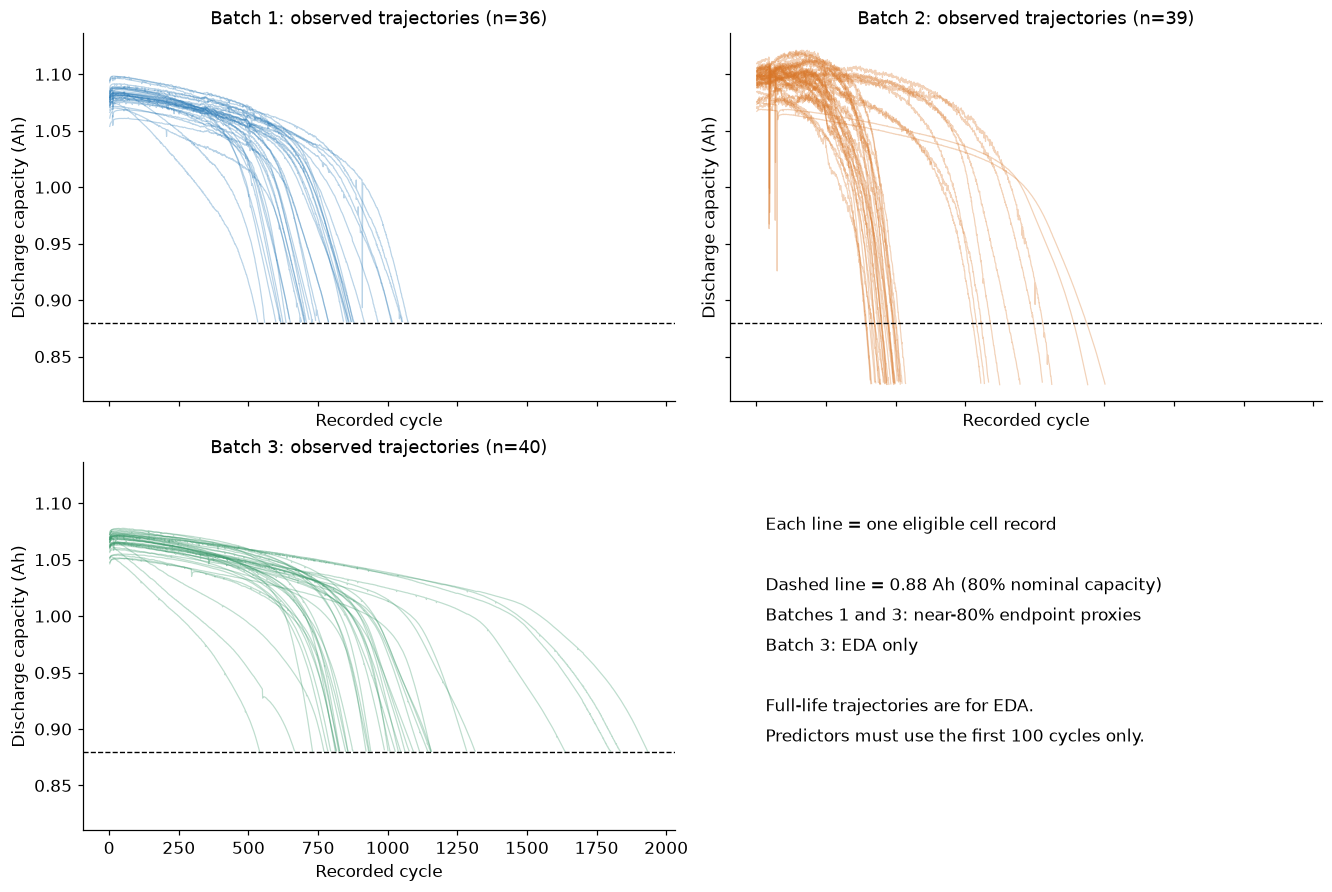

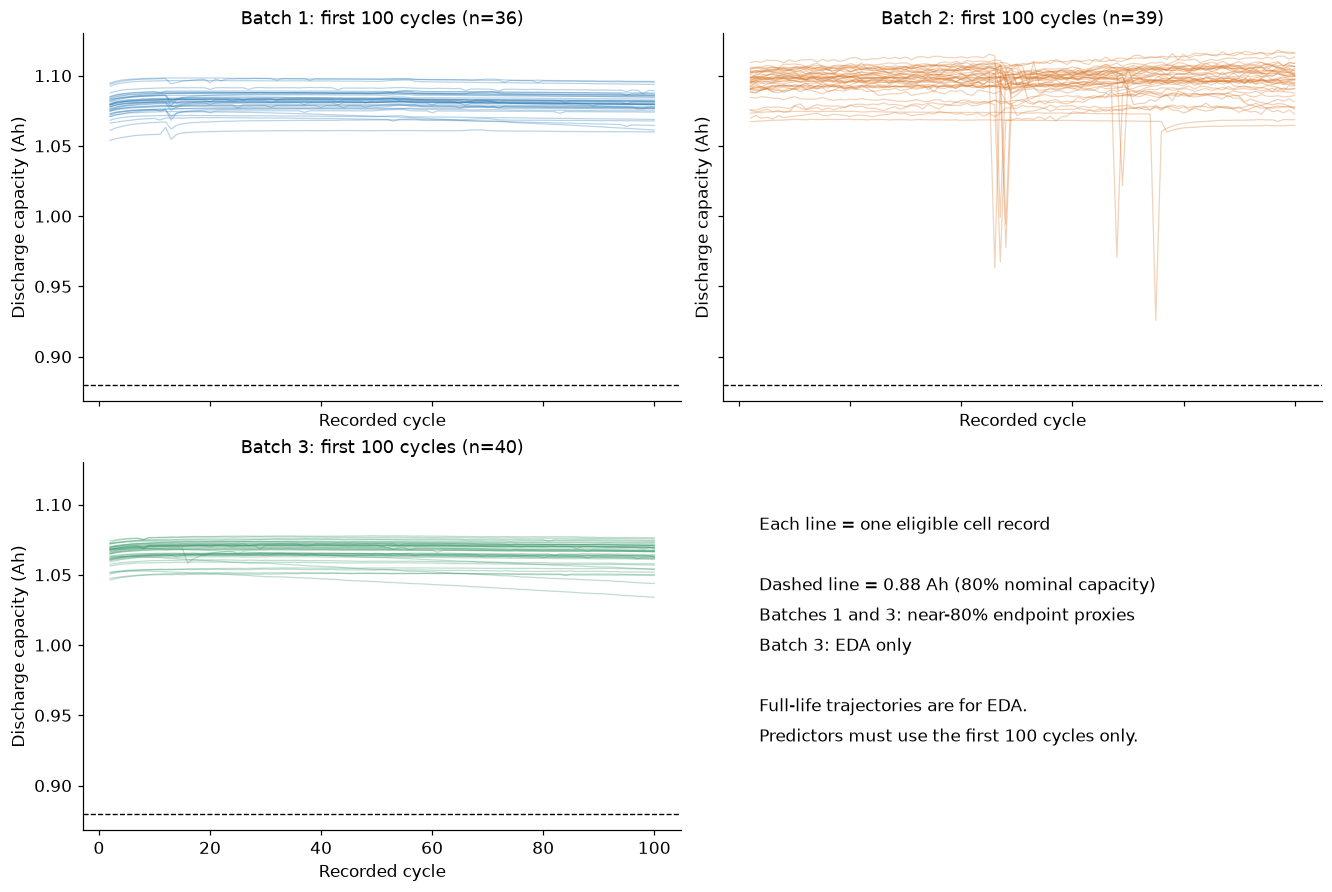

In [7]:
plot_data = summary.loc[summary.capacity_plausible.astype(str).str.lower().eq('true')
                        & summary.cell_id.isin(eligible.cell_id) & summary.cycle.ge(2)].copy()
# 마지막 용량의 급락 등 점검 범위 밖 값은 raw summary에 남아 있다.
# 3개 배치를 같은 축 범위로 비교하고 네 번째 칸에 읽는 법을 둔다.
for early_only in [False, True]:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True,
                             layout='constrained')
    for ax, batch in zip(axes.flat, BATCHES):
        selected = plot_data.loc[plot_data.batch.eq(batch)]
        if early_only:
            selected = selected.loc[selected.cycle.le(100)]
        for cell_id, group in selected.groupby('cell_id'):
            group = group.sort_values('cycle')
            ax.plot(group.cycle, group.QDischarge, color=COLORS[batch], alpha=.32, linewidth=.8)
        ax.axhline(.88, color='black', linestyle='--', linewidth=.9)
        title = 'first 100 cycles' if early_only else 'observed trajectories'
        ax.set(title=f'{batch}: {title} (n={selected.cell_id.nunique()})',
               xlabel='Recorded cycle', ylabel='Discharge capacity (Ah)')
    axes[1, 1].set_axis_off()
    axes[1, 1].text(.06, .87,
        'Each line = one eligible cell record\n\n'
        'Dashed line = 0.88 Ah (80% nominal capacity)\n'
        'Batches 1 and 3: near-80% endpoint proxies\n'
        'Batch 3: EDA only\n\n'
        'Full-life trajectories are for EDA.\n'
        'Predictors must use the first 100 cycles only.',
        transform=axes[1, 1].transAxes, va='top', linespacing=1.8)
    plt.show()


In [8]:
from review_day1 import knee_fit

knee_rows = []
for batch, group in eligible.groupby('batch'):
    representative = group.assign(distance=(group.cycle_life-group.cycle_life.median()).abs()).sort_values(
        ['distance', 'cell_id']).iloc[0]
    trace = summary.loc[summary.cell_id.eq(representative.cell_id)
        & summary.capacity_plausible.astype(str).str.lower().eq('true')
        & summary.cycle.between(10, representative.cycle_life)].sort_values('cycle')
    x = trace.cycle.to_numpy()
    y = trace.QDischarge.rolling(7, center=True, min_periods=1).median().to_numpy()
    approximate = knee_fit(x, y, representative.cycle_life)
    knee_rows.append({'batch': batch, 'cell_id': representative.cell_id,
        'provided_life': representative.cycle_life, 'approximate_knee': approximate['cycle'],
        'before_slope': approximate['before_slope'], 'after_slope': approximate['after_slope'],
        'search_10_90': knee_fit(x, y, representative.cycle_life, .1, .9)['cycle'],
        'search_20_95': knee_fit(x, y, representative.cycle_life, .2, .95)['cycle']})
display(pd.DataFrame(knee_rows))
display(eligible.assign(nonnegative=eligible.qd_slope_10_100.ge(0)).groupby('batch').nonnegative.sum()
        .rename('nonnegative_initial_slope_cells').to_frame())


,batch,cell_id,provided_life,approximate_knee,before_slope,after_slope,search_10_90,search_20_95
0,Batch 1,b1c11,788.0,593,-0.000063,-0.000720,593,593
1,Batch 2,b2c16,472.0,339,-0.000157,-0.001152,339,339
2,Batch 3,b3c25,989.0,823,-0.000060,-0.000782,823,823


,nonnegative_initial_slope_cells
batch,
Batch 1,7
Batch 2,22
Batch 3,1


각 배치의 수명 중앙값에 가장 가까운 대표 셀을 먼저 고르고, 동률이면 셀 ID순으로 선택했습니다.
10사이클부터 제공 수명까지의 곡선을 7개 구간 이동 중앙값으로 완화한 뒤,
서로 이어지는 두 직선으로 기울기가 달라지는 위치를 탐색했습니다.
제공 수명의 20~90% 범위에서 후기 기울기가 더 음수인 후보 중 제곱오차가 가장 작은 위치를 사용했습니다.

탐색적 근사는 B1 `b1c11` 약 590, B2 `b2c16` 약 340, B3 `b3c25` 약 820사이클이었습니다.
탐색 범위를 10~90%·20~95%로 바꾸어도 같은 위치가 나왔습니다.
이는 대표 곡선을 설명하는 **근사 위치**이며, 검증된 knee 검출 방법이나 전체 배터리의 공통 임계점은 아닙니다.

초기 기울기가 0 이상인 셀도 B1 7/36, B2 22/39, B3 1/40개였습니다.
초기에는 용량이 유지되거나 증가하다가 후기 감소가 가팔라지는 경우가 있어 일정한 열화 속도를 가정하기 어렵습니다.
초기 기울기와 ΔQ를 후보로 검토하되, 미래 관측이 필요한 knee 위치는 예측 입력에서 제외합니다.


## 5. ΔQ(V): 초기 방전곡선의 변화

같은 전압에서의 용량 차이를 `ΔQ(V) = Q100(V) − Q10(V)`로 계산합니다.
차이곡선의 평균·최솟값·분산은 초기 용량 총량만으로 드러나지 않는 변화를 요약합니다.
분산은 표본분산(`ddof=1`)을 사용하고 `log10`을 적용했습니다.

배열 인덱스와 실제 사이클 번호가 다를 수 있어, 추출된 사이클 위치·곡선 길이·전압 격자·유한값을 확인합니다.
0 분산을 임의의 작은 수로 바꾸어 로그값을 만들지는 않습니다.

**B3의 비교 한계:** 과제 참고 자료에는 배치에 따라 방전곡선 시작 조건이 다를 수 있다는 설명이 있습니다.
공통 전압 격자를 확인해 같은 셀의 100–10 차이를 계산했더라도 시작 조건의 영향이 제거되었다고 볼 수는 없습니다.
따라서 B3의 ΔQ 절댓값 차이를 곧바로 열화 정도 차이로 해석하지 않고, 배치별 조건과 함께 살펴봅니다.


,checked_cells,voltage_points_min,voltage_points_max
batch,,,
Batch 1,36,1000,1000
Batch 2,39,1000,1000
Batch 3,40,1000,1000


,batch,cell_id,voltage_points,slot10,slot100,recomputed_log10_var
0,Batch 1,b1c5,1000,9,99,-4.178443
36,Batch 2,b2c0,1000,9,99,-3.486830
75,Batch 3,b3c0,1000,9,99,-4.244680


모든 사용 가능 곡선의 격자·유한값·차이·분산 검증 통과


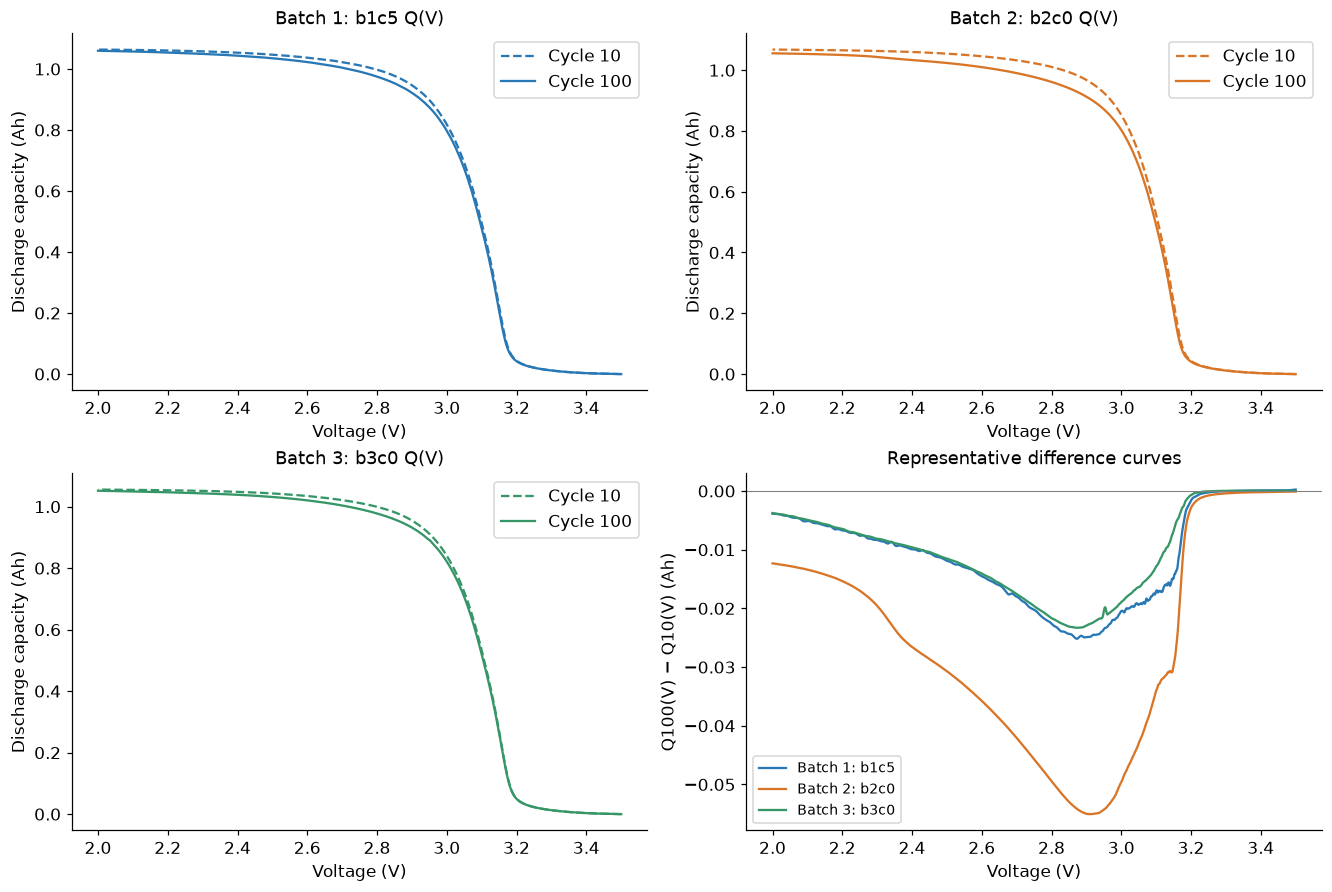

In [9]:
available = eligible.loc[eligible.cell_id.map(lambda k: f'{k}_q10' in curves
                                             and f'{k}_q100' in curves)].copy()
if available.empty:
    raise ValueError('검증 가능한 cycle 10/100 곡선이 없습니다. curve_issue를 먼저 확인하세요.')
curve_checks = []
for row in available.itertuples():
    cid = row.cell_id
    v, q10, q100 = (curves[f'{cid}_{name}'] for name in ['voltage', 'q10', 'q100'])
    assert len(v) == len(q10) == len(q100), cid
    assert np.isfinite(np.r_[v, q10, q100]).all(), cid
    assert np.all(np.diff(v) > 0) or np.all(np.diff(v) < 0), f'{cid}: voltage grid'
    delta = q100 - q10
    assert np.allclose(delta, curves[f'{cid}_deltaq']), cid
    variance = np.var(delta, ddof=1)  # MATLAB var와 같은 표본분산
    assert variance > 0, f'{cid}: zero variance'
    assert np.isclose(np.log10(variance), row.log10_deltaq_var), cid
    curve_checks.append({'batch': row.batch, 'cell_id': cid, 'voltage_points': len(v),
                         'slot10': row.curve_slot10_zero_based,
                         'slot100': row.curve_slot100_zero_based,
                         'recomputed_log10_var': np.log10(variance)})
checked = pd.DataFrame(curve_checks)
display(checked.groupby('batch').agg(checked_cells=('cell_id', 'nunique'),
        voltage_points_min=('voltage_points', 'min'), voltage_points_max=('voltage_points', 'max')))
display(checked.groupby('batch').head(1))
print('모든 사용 가능 곡선의 격자·유한값·차이·분산 검증 통과')

# 각 배치에서 대표 1개를 확인한다. 전체 차이곡선 비교는 다음 셀에서 한다.
fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout='constrained')
for ax, batch in zip(axes.flat, BATCHES):
    sample = available.loc[available.batch.eq(batch)].iloc[0]
    cid = sample.cell_id
    v = curves[f'{cid}_voltage']
    ax.plot(v, curves[f'{cid}_q10'], label='Cycle 10', color=COLORS[batch], linestyle='--')
    ax.plot(v, curves[f'{cid}_q100'], label='Cycle 100', color=COLORS[batch])
    ax.set(title=f'{batch}: {cid} Q(V)', xlabel='Voltage (V)', ylabel='Discharge capacity (Ah)')
    ax.legend()
    axes[1, 1].plot(v, curves[f'{cid}_deltaq'], label=f'{batch}: {cid}', color=COLORS[batch])
axes[1, 1].axhline(0, color='grey', linewidth=.7)
axes[1, 1].set(title='Representative difference curves', xlabel='Voltage (V)',
               ylabel='Q100(V) − Q10(V) (Ah)')
axes[1, 1].legend(fontsize=9)
plt.show()


전체 차이곡선은 장수명·중간·단수명 그룹으로 나누었습니다. 곡선의 모양과 통계값 중앙값을 함께 비교합니다.
B1·B3에는 단수명 셀이 없어 같은 배치 안에서 양극단을 직접 비교할 수 없습니다. B2 장수명도 3개뿐이므로
그룹 차이를 모든 배터리에 일반화하기는 어렵습니다. 아래 전체 배치 비교는 설명용이며 모델 선택에는 사용하지 않습니다.


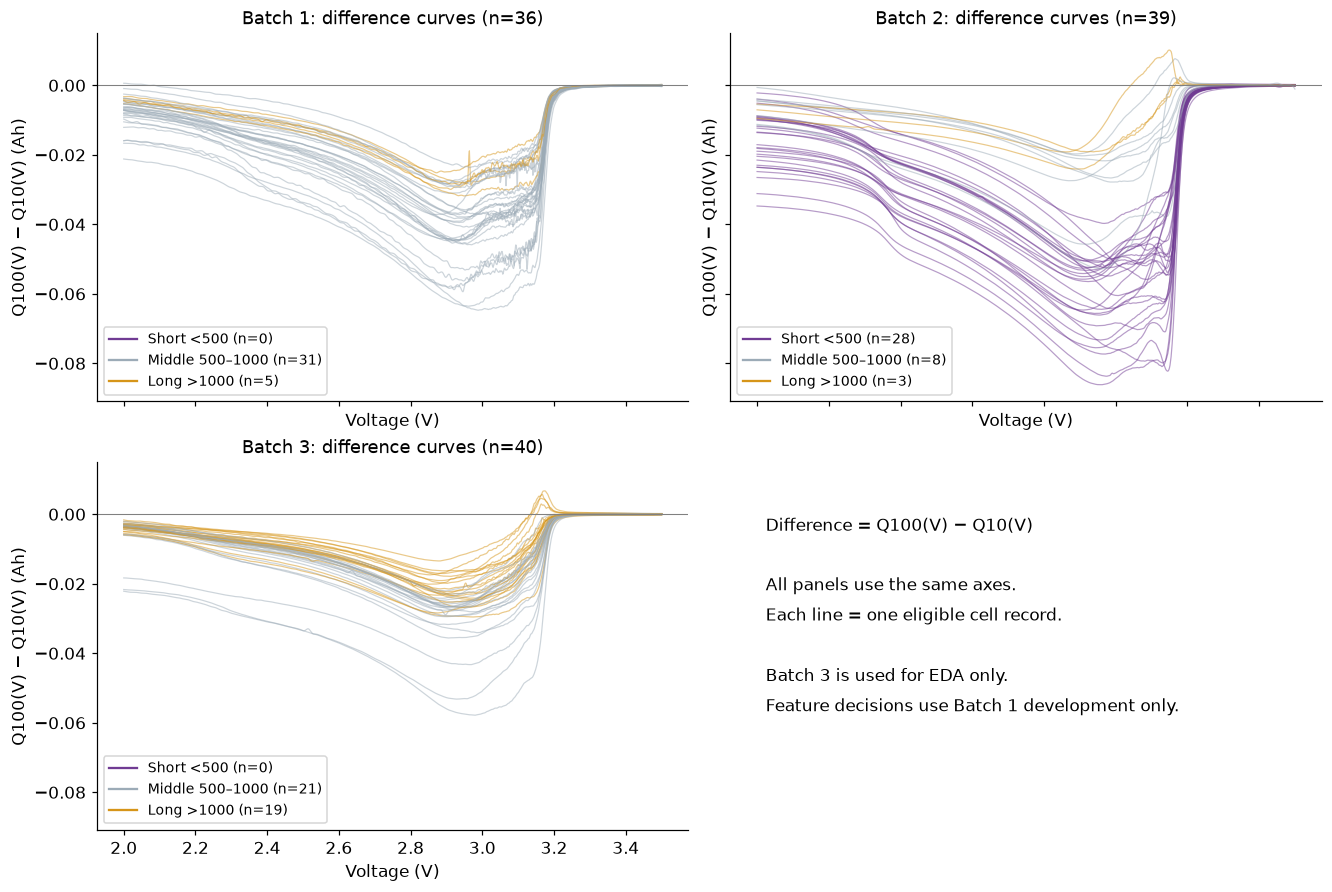

n  valid_logvar  median_logvar  median_deltaq_mean  \
batch   life_group                                                         
Batch 1 Short: <500   0             0            NaN                 NaN   
        Long: >1000   5             5        -4.0589             -0.0124   
Batch 2 Short: <500  28            28        -3.4457             -0.0287   
        Long: >1000   3             3        -4.2713             -0.0081   
Batch 3 Short: <500   0             0            NaN                 NaN   
        Long: >1000  19            19        -4.2851             -0.0096   

                     median_deltaq_min  
batch   life_group                      
Batch 1 Short: <500                NaN  
        Long: >1000            -0.0287  
Batch 2 Short: <500            -0.0562  
        Long: >1000            -0.0192  
Batch 3 Short: <500                NaN  
        Long: >1000            -0.0223

중앙값 비교는 EDA용입니다. 그룹 표본 수를 함께 보고, 평가셋으로 피처를 고르지 않습니다.


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True, layout='constrained')
for ax, batch in zip(axes.flat, BATCHES):
    selected = available.loc[available.batch.eq(batch)]
    for row in selected.itertuples():
        cid = row.cell_id
        color = '#703B93' if row.cycle_life < 500 else '#D69519' if row.cycle_life > 1000 else '#9CABB7'
        ax.plot(curves[f'{cid}_voltage'], curves[f'{cid}_deltaq'],
                color=color, alpha=.5, linewidth=.8)
    for label, color, n in [
        ('Short <500', '#703B93', int(selected.cycle_life.lt(500).sum())),
        ('Middle 500–1000', '#9CABB7', int(selected.cycle_life.between(500, 1000).sum())),
        ('Long >1000', '#D69519', int(selected.cycle_life.gt(1000).sum()))]:
        ax.plot([], [], color=color, label=f'{label} (n={n})')
    ax.legend(fontsize=9)
    ax.axhline(0, color='grey', linewidth=.7)
    ax.set(title=f'{batch}: difference curves (n={len(selected)})',
           xlabel='Voltage (V)', ylabel='Q100(V) − Q10(V) (Ah)')
axes[1, 1].set_axis_off()
axes[1, 1].text(.06, .87,
    'Difference = Q100(V) − Q10(V)\n\n'
    'All panels use the same axes.\n'
    'Each line = one eligible cell record.\n\n'
    'Batch 3 is used for EDA only.\n'
    'Feature decisions use Batch 1 development only.',
    transform=axes[1, 1].transAxes, va='top', linespacing=1.8)
plt.show()

delta_groups = available[['batch', 'cell_id', 'cycle_life', 'log10_deltaq_var', 'deltaq_mean', 'deltaq_min']].copy()
delta_groups['life_group'] = np.select(
    [delta_groups.cycle_life < 500, delta_groups.cycle_life > 1000],
    ['Short: <500', 'Long: >1000'], default='Middle: 500–1000')
delta_extremes = delta_groups.loc[delta_groups.life_group.ne('Middle: 500–1000')]
group_delta_stats = delta_extremes.groupby(['batch', 'life_group']).agg(
    n=('cell_id', 'size'), valid_logvar=('log10_deltaq_var', 'count'),
    median_logvar=('log10_deltaq_var', 'median'),
    median_deltaq_mean=('deltaq_mean', 'median'),
    median_deltaq_min=('deltaq_min', 'median')).reindex(
        pd.MultiIndex.from_product([list(BATCHES), ['Short: <500', 'Long: >1000']],
                                   names=['batch', 'life_group']))
group_delta_stats[['n', 'valid_logvar']] = group_delta_stats[['n', 'valid_logvar']].fillna(0).astype(int)
display(group_delta_stats.round(4))
print('중앙값 비교는 EDA용입니다. 그룹 표본 수를 함께 보고, 평가셋으로 피처를 고르지 않습니다.')


B2 단수명 28개의 ΔQ 로그분산 중앙값은 약 -3.45, 장수명 3개는 약 -4.27이었습니다.
평균·최솟값도 함께 보면 단수명 그룹의 차이가 더 음수이고 전압에 따른 변화가 큰 경향을 보였습니다.
B1·B3에는 단수명 그룹이 없으므로 같은 관계를 해당 배치 안에서 직접 확인했다고 표현하지 않았습니다.

B1 개발용 28개에서 ΔQ 평균·최솟값·로그분산과 수명의 상관은 각각 +0.723, +0.764, -0.782였습니다.
세 통계 사이의 |r|도 0.966~0.990으로 높아 한꺼번에 넣으면 비슷한 정보를 중복할 수 있습니다.
로그분산을 우선 후보로 두고 평균·최솟값 대체 조합을 같은 교차검증 조건에서 비교하도록 설계했습니다.


## 6. 충전 조건과 수명·후반 열화의 관계

평균 수명이 높은 충전 방식이 언제나 더 좋다는 뜻은 아닙니다. 표본 수와 실험 조건이 다르므로
배치 안에서 전체 충전 방식별 **셀 수·평균 수명·후반 기울기**를 함께 비교했습니다.
전체 표는 배치×정책 **40개 그룹**이며, 서로 다른 정책 문자열은 **37개**입니다.

기록된 `첫 C-rate(SOC%)-후속 C-rate`에서 세 조건을 구분했습니다.
후반 기울기는 제공 수명의 80% 시점부터 종료까지의 QD 선형 기울기(Ah/사이클)입니다.
더 음수일수록 용량 감소가 가파릅니다. 이 값은 전체 수명을 관찰한 EDA용이며 초기 예측 입력으로 사용하지 않습니다.
`newstructure`는 원자료의 문자열을 유지했으며 물리적 의미를 임의로 해석하지 않았습니다.


In [11]:
from supplement_day1 import build_supplement

# 같은 입력에서 보완 통계만 재계산합니다. 이 함수는 파일을 쓰거나 모델을 학습하지 않습니다.
supplement = build_supplement(ROOT)
saved_supplement = json.loads(SUPPLEMENT_PATH.read_text())
assert supplement == saved_supplement, '보완 분석 입력 또는 저장 결과를 확인해 주세요.'
policy_conditions = pd.DataFrame(supplement['policy_correlations'])
policy_stats = pd.DataFrame(supplement['policy_groups'])
assert len(policy_stats) == 40 and policy_stats.n.sum() == len(eligible)
print('배치별 충전 조건과 후반 기울기의 Pearson 상관계수입니다.')
display(policy_conditions[['batch', 'predictor', 'n', 'pearson_r']].round(3))
print('전체 40개 배치·정책 그룹입니다. 기울기의 단위는 Ah/사이클입니다.')
with pd.option_context('display.max_rows', 50, 'display.max_colwidth', 50):
    display(policy_stats[['batch', 'policy', 'n', 'mean_life', 'late_slope_n',
                          'late_slope_mean', 'late_slope_median']].round(
                              {'mean_life': 1, 'late_slope_mean': 6, 'late_slope_median': 6}))
print('셀이 1개뿐인 그룹:', supplement['counts']['singleton_groups'])
print('같은 첫 전류 8C·후속 전류 3.6C에서 전환 SOC를 비교합니다.')
display(pd.DataFrame(supplement['same_current_soc_example'])[
    ['transition_soc_pct', 'n', 'mean_life', 'late_slope_mean', 'late_slope_median']].round(6))


배치별 충전 조건과 후반 기울기의 Pearson 상관계수입니다.


,batch,predictor,n,pearson_r
0,Batch 1,c_rate_stage1,36,-0.279
1,Batch 1,c_rate_stage2,36,-0.079
2,Batch 1,transition_soc_pct,36,-0.043
3,Batch 2,c_rate_stage1,39,-0.038
4,Batch 2,c_rate_stage2,39,0.236
5,Batch 2,transition_soc_pct,39,0.003
6,Batch 3,c_rate_stage1,40,-0.493
7,Batch 3,c_rate_stage2,40,0.401
8,Batch 3,transition_soc_pct,40,0.275


전체 40개 배치·정책 그룹입니다. 기울기의 단위는 Ah/사이클입니다.


,batch,policy,n,mean_life,late_slope_n,late_slope_mean,late_slope_median
0,Batch 1,4.4C(80%)-4.4C,1,1074.0,1,-0.000642,-0.000642
1,Batch 1,4.8C(80%)-4.8C,2,753.0,2,-0.000971,-0.000971
2,Batch 1,5.4C(40%)-3.6C,1,1054.0,1,-0.000627,-0.000627
3,Batch 1,5.4C(50%)-3C,1,788.0,1,-0.000794,-0.000794
4,Batch 1,5.4C(60%)-3.6C,2,859.5,2,-0.000858,-0.000858
5,Batch 1,5.4C(60%)-3C,2,799.5,2,-0.000848,-0.000848
6,Batch 1,5.4C(70%)-3C,2,739.5,2,-0.000863,-0.000863
7,Batch 1,5.4C(80%)-5.4C,2,546.5,2,-0.000858,-0.000858
8,Batch 1,6C(30%)-3.6C,1,1014.0,1,-0.000656,-0.000656
9,Batch 1,6C(40%)-3.6C,2,856.0,2,-0.000800,-0.000800


셀이 1개뿐인 그룹: 4
같은 첫 전류 8C·후속 전류 3.6C에서 전환 SOC를 비교합니다.


,transition_soc_pct,n,mean_life,late_slope_mean,late_slope_median
0,15.0,2,1008.5,-0.000641,-0.000641
1,25.0,2,676.5,-0.000949,-0.000949
2,35.0,2,607.5,-0.001060,-0.001060


B3에서는 첫 C-rate가 클수록 후반 기울기가 더 음수인 경향(r=-0.493)이 있었고,
후속 C-rate와의 r은 +0.401, 전환 SOC와의 r은 +0.275였습니다.
B1·B2에서는 관계가 다르므로 첫 전류 하나로 전체 배치의 열화를 설명하기 어렵습니다.

B1의 첫 8C·후속 3.6C를 사용하는 세 그룹은 SOC 15/25/35%에서 평균 수명이 1008.5/676.5/607.5사이클이고,
후반 기울기는 약 -0.000641/-0.000949/-0.001060Ah/사이클이었습니다(각 2개).
같은 전류에서도 전환 시점과 전체 충전 방식에 따라 다른 열화 양상이 나타났습니다.
다만 세 조건과 배치의 다른 조건이 함께 변하고 표본도 작으므로 독립 효과나 인과효과를 분리한 결과는 아닙니다.


## 7. 초기 변수와 수명의 관계

먼저 **B1 개발용 28개**에서 모델 설계에 사용할 근거를 확인합니다.
초기 변수는 모두 100사이클 이내에 계산했습니다. `qd_slope_10_100`은 용량 기울기이고,
`ir_change_early`는 91~100사이클과 2~10사이클의 양수 내부저항 평균 차이입니다.

Pearson은 선형 관계를, Spearman은 순위에 기반한 단조 관계를 요약합니다.
어느 계수도 인과관계나 최종 예측 성능을 확정하지 않습니다. 아래 개발용 분석 뒤에는 과제의 배치 비교를 위해
전체 B1·B2·B3의 수명 상관과 변수끼리의 상관을 별도로 제시합니다. 이 설명용 결과로 후보를 다시 고르지 않습니다.


In [12]:
FEATURES = ['qd_cycle2', 'qd_change_100_10',
            'qd_slope_10_100', 'ir_mean_2_100', 'ir_change_early',
            'tavg_mean_2_100', 'chargetime_mean_2_100', 'log10_deltaq_var']
train_eda = eligible.loc[eligible.split_role.eq('Batch1_CV_development')].copy()
assert train_eda.batch.eq('Batch 1').all() and len(train_eda) == 28
display(train_eda[FEATURES].isna().sum().rename('missing_in_development').to_frame())
relationship_rows = []
for feature in FEATURES:
    pair = train_eda[[feature, 'cycle_life']].replace([np.inf, -np.inf], np.nan).dropna()
    enough = len(pair) >= 3 and pair[feature].nunique() > 1
    r = pair[feature].corr(pair.cycle_life) if enough else np.nan
    rho = pair[feature].corr(pair.cycle_life, method='spearman') if enough else np.nan
    relationship_rows.append({'feature': feature, 'paired_cells': len(pair),
                              'pearson_r_with_life': r, 'spearman_rho_with_life': rho})
relationships = pd.DataFrame(relationship_rows)
display(relationships.sort_values('pearson_r_with_life', key=lambda s: s.abs(),
                                 ascending=False).round(3))


,missing_in_development
qd_cycle2,0
qd_change_100_10,0
qd_slope_10_100,0
ir_mean_2_100,0
ir_change_early,0
tavg_mean_2_100,0
chargetime_mean_2_100,0
log10_deltaq_var,0


,feature,paired_cells,pearson_r_with_life,spearman_rho_with_life
7,log10_deltaq_var,28,-0.782,-0.782
2,qd_slope_10_100,28,0.545,0.575
1,qd_change_100_10,28,0.518,0.552
6,chargetime_mean_2_100,28,0.463,0.302
5,tavg_mean_2_100,28,-0.172,-0.073
0,qd_cycle2,28,0.155,0.171
4,ir_change_early,28,0.132,-0.278
3,ir_mean_2_100,28,0.074,0.031


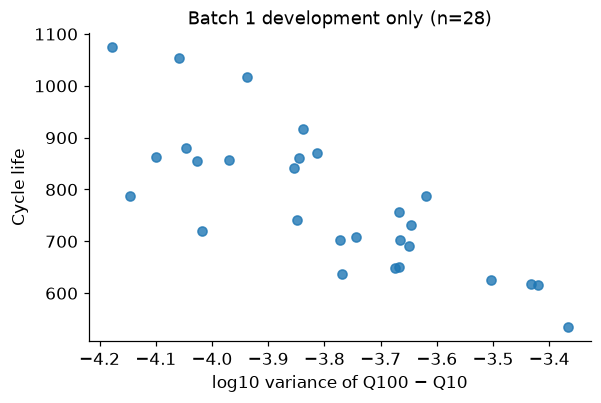

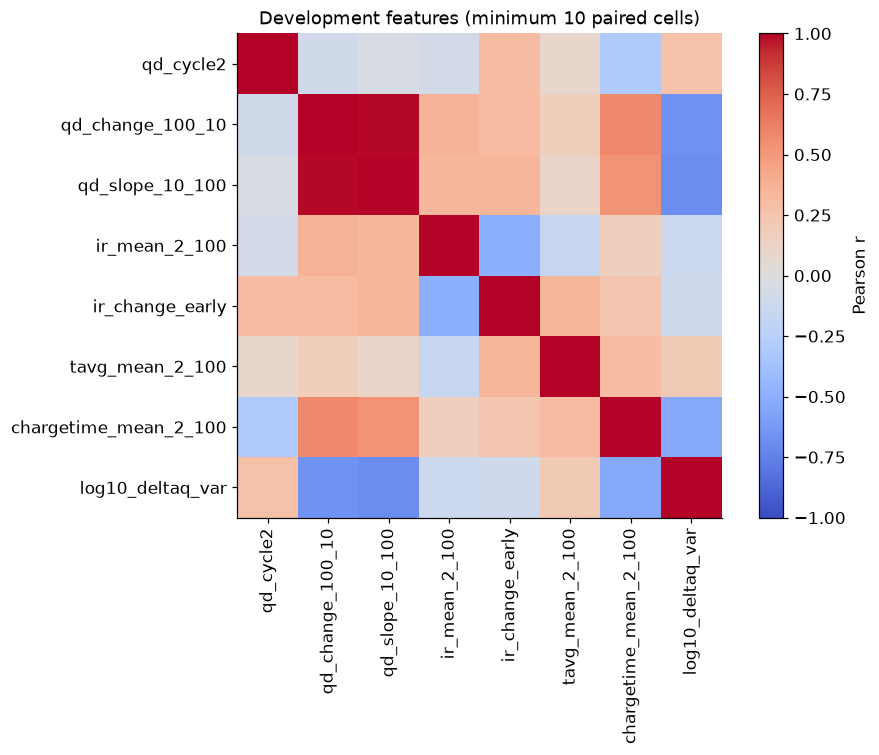

,feature_1,feature_2,r
0,qd_change_100_10,qd_slope_10_100,0.985


In [13]:
pair = train_eda[['log10_deltaq_var', 'cycle_life', 'cell_id']].dropna()
fig, ax = plt.subplots(figsize=(5.6, 3.8))
ax.scatter(pair.log10_deltaq_var, pair.cycle_life, alpha=.8)
ax.set(xlabel='log10 variance of Q100 − Q10', ylabel='Cycle life',
       title=f'Batch 1 development only (n={len(pair)})')
plt.tight_layout()
plt.show()

corr = train_eda[FEATURES].corr(min_periods=10)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(FEATURES)), FEATURES, rotation=90)
ax.set_yticks(range(len(FEATURES)), FEATURES)
ax.set_title('Development features (minimum 10 paired cells)')
fig.colorbar(im, ax=ax, label='Pearson r')
plt.tight_layout()
plt.show()
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
strong = upper.loc[upper.abs() >= .85].rename('r').reset_index()
strong.columns = ['feature_1', 'feature_2', 'r']
display(strong.round(3))


### 배치별 상관 비교와 다중공선성

수명과 각 변수의 상관은 예측 신호를 살피는 용도이고, 변수끼리의 상관은 중복 정보를 확인하는 용도입니다.
두 질문을 구분해 전체 배치에서 비교합니다. 결측값을 대치하지 않고 각 변수쌍의 유효한 셀만 사용했으므로
표본 수 `n`을 함께 확인합니다. |r|≥0.85는 설명용으로 강한 쌍을 정리하는 기준이며 통계적 유의성 판정이나 자동 제거 규칙은 아닙니다.


In [14]:
batch_target_rows = []
for batch, group in eligible.groupby('batch'):
    for feature in FEATURES:
        pair = group[[feature, 'cycle_life']].replace([np.inf, -np.inf], np.nan).dropna()
        batch_target_rows.append({'batch': batch, 'feature': feature, 'n': len(pair),
                                  'pearson_r': pair[feature].corr(pair.cycle_life)})
batch_targets = pd.DataFrame(batch_target_rows)
print('각 변수와 수명의 상관입니다.')
display(batch_targets.pivot(index='feature', columns='batch', values='pearson_r').reindex(FEATURES).round(3))
display(batch_targets.pivot(index='feature', columns='batch', values='n').reindex(FEATURES))

all_feature_pairs = pd.DataFrame(supplement['feature_correlations'])
short_labels = dict(zip(FEATURES, ['QD2', 'Delta QD', 'QD slope', 'Mean IR', 'Delta IR',
                                 'Mean temp', 'Charge time', 'Log var DQ']))
for batch in BATCHES:
    one = all_feature_pairs.loc[all_feature_pairs.batch.eq(batch)]
    matrix = one.pivot(index='feature_1', columns='feature_2', values='pearson_r').reindex(index=FEATURES, columns=FEATURES)
    ns = one.pivot(index='feature_1', columns='feature_2', values='n').reindex(index=FEATURES, columns=FEATURES)
    assert np.allclose(matrix, matrix.T, equal_nan=True)
    print(batch, '변수끼리의 Pearson r과 각 쌍의 표본 수 n입니다.')
    display(matrix.rename(index=short_labels, columns=short_labels).round(3))
    display(ns.rename(index=short_labels, columns=short_labels))
print('각 배치에서 |r|≥0.85인 독립 변수쌍입니다.')
display(pd.DataFrame(supplement['strong_pairs'])[['batch', 'feature_1', 'feature_2', 'n', 'pearson_r']].round(3))


각 변수와 수명의 상관입니다.


batch,Batch 1,Batch 2,Batch 3
feature,,,
qd_cycle2,0.161,-0.284,0.236
qd_change_100_10,0.504,-0.187,0.317
qd_slope_10_100,0.516,-0.484,0.353
ir_mean_2_100,0.224,-0.626,0.201
ir_change_early,0.121,0.211,-0.264
tavg_mean_2_100,-0.173,0.425,-0.039
chargetime_mean_2_100,0.570,-0.917,0.598
log10_deltaq_var,-0.827,-0.902,-0.742


batch,Batch 1,Batch 2,Batch 3
feature,,,
qd_cycle2,36,39,40
qd_change_100_10,36,39,40
qd_slope_10_100,36,39,40
ir_mean_2_100,36,33,40
ir_change_early,36,33,40
tavg_mean_2_100,36,39,40
chargetime_mean_2_100,36,39,40
log10_deltaq_var,36,39,40


Batch 1 변수끼리의 Pearson r과 각 쌍의 표본 수 n입니다.


feature_2,QD2,Delta QD,QD slope,Mean IR,Delta IR,Mean temp,Charge time,Log var DQ
feature_1,,,,,,,,
QD2,1.000,-0.149,-0.122,-0.069,0.295,-0.087,-0.243,0.239
Delta QD,-0.149,1.000,0.986,0.480,0.269,0.128,0.600,-0.656
QD slope,-0.122,0.986,1.000,0.449,0.303,0.094,0.557,-0.678
Mean IR,-0.069,0.480,0.449,1.000,-0.422,-0.200,0.304,-0.271
Delta IR,0.295,0.269,0.303,-0.422,1.000,0.250,0.215,-0.081
Mean temp,-0.087,0.128,0.094,-0.200,0.250,1.000,0.220,0.139
Charge time,-0.243,0.600,0.557,0.304,0.215,0.220,1.000,-0.624
Log var DQ,0.239,-0.656,-0.678,-0.271,-0.081,0.139,-0.624,1.000


...

Batch 3 변수끼리의 Pearson r과 각 쌍의 표본 수 n입니다.


feature_2,QD2,Delta QD,QD slope,Mean IR,Delta IR,Mean temp,Charge time,Log var DQ
feature_1,,,,,,,,
QD2,1.000,0.133,0.142,-0.030,0.111,-0.325,0.047,0.046
Delta QD,0.133,1.000,0.993,0.703,-0.831,-0.254,0.056,-0.658
QD slope,0.142,0.993,1.000,0.702,-0.836,-0.251,0.090,-0.688
Mean IR,-0.030,0.703,0.702,1.000,-0.693,-0.187,0.019,-0.425
Delta IR,0.111,-0.831,-0.836,-0.693,1.000,0.213,-0.024,0.701
Mean temp,-0.325,-0.254,-0.251,-0.187,0.213,1.000,-0.228,0.062
Charge time,0.047,0.056,0.090,0.019,-0.024,-0.228,1.000,-0.493
Log var DQ,0.046,-0.658,-0.688,-0.425,0.701,0.062,-0.493,1.000


feature_2,QD2,Delta QD,QD slope,Mean IR,Delta IR,Mean temp,Charge time,Log var DQ
feature_1,,,,,,,,
QD2,40,40,40,40,40,40,40,40
Delta QD,40,40,40,40,40,40,40,40
QD slope,40,40,40,40,40,40,40,40
Mean IR,40,40,40,40,40,40,40,40
Delta IR,40,40,40,40,40,40,40,40
Mean temp,40,40,40,40,40,40,40,40
Charge time,40,40,40,40,40,40,40,40
Log var DQ,40,40,40,40,40,40,40,40


각 배치에서 |r|≥0.85인 독립 변수쌍입니다.


,batch,feature_1,feature_2,n,pearson_r
0,Batch 1,qd_change_100_10,qd_slope_10_100,36,0.986
1,Batch 2,qd_change_100_10,qd_slope_10_100,39,0.889
2,Batch 2,chargetime_mean_2_100,log10_deltaq_var,39,0.957
3,Batch 3,qd_change_100_10,qd_slope_10_100,40,0.993


8개 후보 중 B1·B3에서는 ΔQ 로그분산(r=-0.827/-0.742), B2에서는 충전 시간(r=-0.917)이
수명과 가장 강한 선형 관계를 보였습니다. 충전 시간과 수명의 상관 부호가 배치에 따라 달라
같은 변수 관계가 그대로 유지된다고 가정하기 어렵습니다.

용량 변화량과 기울기의 상관은 전체 B1/B2/B3에서 0.986/0.889/0.993으로 높았습니다.
B2에서는 충전 시간과 ΔQ 로그분산도 0.957이었습니다.
특성 사이의 중복 정도가 배치별로 다를 수 있다는 관찰이며, 모델 설계의 변수 제거·Ridge 비교는 B1 개발용 근거로 정했습니다.
보완된 B2·B3 결과로 기존 특성 집합이나 모델을 다시 선택하지 않았습니다.


## 8. EDA 결과를 반영한 모델 설계

| 확인한 근거 | 모델 설계에 반영한 내용 |
|---|---|
| B1보다 B2에 짧은 수명이 많습니다. | B1 개발/holdout과 B2 평가를 구분하고 배치 간 일반화를 확인합니다. |
| 초기 용량만으로 수명 차이가 충분히 드러나지 않습니다. | 평균 예측을 기준선으로 두고 초기 변화량·기울기와 ΔQ를 비교합니다. |
| ΔQ 로그분산이 B1 개발용 수명과 관련이 있고 평균·최솟값과 중복됩니다. | 로그분산을 우선 후보로 사용하며 평균·최솟값으로 대체한 경우도 같은 CV에서 비교합니다. |
| 용량 변화량과 기울기의 상관이 높습니다. | 하나를 제외한 조합과 Ridge를 비교해 중복 정보의 영향을 확인합니다. |
| 온도·저항·충전 시간이 추가 정보를 줄 수 있습니다. | 소수 변수를 조합한 Linear·Ridge와 비선형 관계를 확인하는 Random Forest를 비교합니다. |
| B2의 초기 저항에 결측이 있고 표본 수가 적습니다. | 대치·표준화는 각 훈련 fold 안에서만 적용하고, 저항 제외 조합도 비교합니다. |

Random Forest는 학습한 수명의 범위 밖으로 예측하기 어려우므로, B1보다 짧은 B2 수명에 한계가 있을 수 있습니다.
Linear·Ridge는 범위 밖 예측이 가능하지만 배치가 바뀌어도 같은 관계가 유지된다는 보장은 없습니다.
따라서 **모델 선택은 B1 개발용 교차검증의 MAPE**로 진행하도록 설계했습니다.
별도 holdout과 B2에서는 MAPE, MAE, RMSE, R² 및 오차 사례를 확인합니다.

수업의 전처리·교차검증 원칙에 따라 같은 충전 정책이 한 CV fold의 학습·검증에 섞이지 않도록 그룹을 구분합니다.
고정 holdout은 셀 단위로 분리되어 있으며, 정책까지 모두 처음 보는 데이터라고 주장하지 않습니다.
B2 정답을 보고 제외 기준이나 특성·모델을 바꾸어 같은 B2를 새로운 미관측 테스트로 제시하지 않습니다.
전체 기록 길이·최종 용량·후반 기울기·knee 근사 위치는 예측 입력에서 제외합니다.


## 9. 분석의 결론과 한계

분석 대상은 B1 36개, B2 39개, B3 40개입니다. 수명 중앙값은 각각 772.5, 472.0, 964.5사이클로 달랐습니다.
B1·B3에는 500사이클 미만의 단수명이 없었고, B2에서는 28/39개가 해당했습니다.
따라서 B1 내부 검증이 좋아도 B2에서 같은 수준의 성능이 나온다고 단정할 수 없습니다.

초기 변화가 작다는 이유만으로 오래 사용할 수 있다고 판단하기도 어렵습니다.
ΔQ와 용량 추세를 함께 검토하되 중복 변수와 결측값을 고려하고, 배치 차이는 별도 평가에서 확인하도록 설계했습니다.
충전 조건과 열화의 관계는 실험 조건이 함께 달라진 관찰 결과이므로 원인과 결과로 확정하지 않았습니다.

B1·B3의 제공 근사 종료 라벨과 B2의 관측 교차 라벨은 정의가 완전히 같지 않습니다.
B3의 방전곡선 시작 조건 차이, 작은 정책별 표본, 미해독 물리 셀 식별자도 한계로 남습니다.
이 노트북의 후반 열화와 knee 분석은 데이터 설명용이며, 그 값을 초기 수명 예측에 넣지 않습니다.
DAY2 결과는 별도 노트북에 있으며, 이번 보완 통계로 이미 선택한 모델을 다시 선택하거나 학습하지 않았습니다.

### 참고와 재현 범위

- [과제 안내](https://actually-war-1ea.notion.site/DS-Mini-Project-32d7f4c8669380338a27f90c471c1fcb)
- [Severson 등, Nature Energy 2019 원논문](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)
- [원저자 데이터 처리 저장소](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation)
- 원본·제외·라벨은 `data/processed/cells_analysis.csv`에서 확인할 수 있습니다.
- 충전 패턴과 배치별 변수 상관의 보완 표는 `src/supplement_day1.py`로 다시 계산할 수 있습니다.
  전체 정책 표와 상관계수별 표본 수는 `results/day1_supplement_*.csv`에 저장됩니다.
- 대표 knee 근사는 기존 `src/review_day1.py`의 방법을 해당 분석 셀에서 재계산했습니다.
  배치·정제·분할 조건이 논문과 다르므로 논문의 9.1%를 동일 조건으로 재현했다고 주장하지 않습니다.


In [15]:
input_hashes_after = {str(p.relative_to(ROOT)): hashlib.sha256(p.read_bytes()).hexdigest()
                      for p in protected_paths}
assert input_hashes_before == input_hashes_after, '입력 파일 변경 여부를 확인해 주세요.'
assert len(eligible) == 115 and len(train_eda) == 28
assert len(policy_stats) == 40 and len(all_feature_pairs) == 192
print('원본 추출표·정제 대상·기존 분할의 해시가 실행 전후 동일합니다.')
print('DAY1 분석 셀 실행을 마쳤으며, 예측 모델을 학습하거나 다시 선택하지 않았습니다.')


원본 추출표·정제 대상·기존 분할의 해시가 실행 전후 동일합니다.
DAY1 분석 셀 실행을 마쳤으며, 예측 모델을 학습하거나 다시 선택하지 않았습니다.
